In [1]:
import os
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysam
import pyBigWig
import seaborn as sns
from pyBioInfo.Range import GRange
from pyBioInfo.IO.File import GtfFile, GtfGeneBuilder, BedFile
from pyBioInfo.Utils import ShiftLoader

# Soft-clip

In [20]:
bamfile = "results/06_bam_filtered/GSM3452725_K562_PROseq.bam"
counter = defaultdict(int)
with pysam.AlignmentFile(bamfile) as f:
    for i, s in enumerate(f):
        if i >= 1000000:
            break
        cigars = s.cigar
        c1, c2 = 0, 0
        if cigars[0][0] == pysam.CSOFT_CLIP or cigars[0][0] == pysam.CHARD_CLIP:
            c1 = cigars[0][1]
        if cigars[-1][0] == pysam.CSOFT_CLIP or cigars[-1][0] == pysam.CHARD_CLIP:
            c2 = cigars[-1][1]
        if s.is_reverse:
            c1, c2 = c2, c1
        counter[(c1, c2)] += 1

[W::hts_idx_load3] The index file is older than the data file: results/06_bam_filtered/GSM3452725_K562_PROseq.bam.bai


In [21]:
counter1 = defaultdict(int)
counter2 = defaultdict(int)
for (c1, c2), n in counter.items():
    counter1[c1] += n
    counter2[c2] += n

In [26]:
total = sum(counter1.values())
for n1, n2 in sorted(counter1.items()):
    print(n1, n2, n2 / total, sep="\t")

0	24177	0.024177
1	19385	0.019385
2	26709	0.026709
3	50227	0.050227
4	51081	0.051081
5	166963	0.166963
6	643022	0.643022
7	7355	0.007355
8	3751	0.003751
9	1105	0.001105
10	826	0.000826
11	614	0.000614
12	542	0.000542
13	627	0.000627
14	411	0.000411
15	468	0.000468
16	359	0.000359
17	236	0.000236
18	267	0.000267
19	384	0.000384
20	195	0.000195
21	170	0.00017
22	219	0.000219
23	264	0.000264
24	224	0.000224
25	159	0.000159
26	260	0.00026


# Correlation of bins

In [35]:
def generate_bin_coverages(infile1, infile2, outfile, width=1000):
    if os.path.exists(outfile):
        return None        
    step = int(width / 2)
    rows = []
    with open(outfile, 'w+') as fw:
        fw.write('chrom\tstart\tend\tstrand\tcoverage\n')
        for strand, path in zip(["+", "-"], [infile1, infile2]):
            with pyBigWig.open(path) as f:
                for chrom, length in f.chroms().items():
                    n = int(length / step)
                    if length % step > 0:
                        n += 1
                    # print(chrom, length, n, sep='\t')
                    covs = np.zeros(n)
                    for item in f.intervals(chrom):
                        pos = item[1]
                        i = int(pos / step)
                        covs[i] += item[2]
                        if i > 0:
                            covs[i-1] += item[2]
                    for i, cov in enumerate(covs):
                        row = [chrom, i * step, min(i * step + width, length), strand, cov]
                        fw.write('\t'.join(map(str, row)) + '\n')
                        
infile1 = "results/08_bigwigs/GSM2361442_K562_PROseq_NHS_Rep1_raw_pos.bw"
infile2 = "results/08_bigwigs/GSM2361442_K562_PROseq_NHS_Rep1_raw_neg.bw"
outfile = "analysis/GSM2361442_K562_PROseq_NHS_Rep1.tsv"
generate_bin_coverages(infile1, infile2, outfile)

infile1 = "results/08_bigwigs/GSM2361443_K562_PROseq_NHS_Rep2_raw_pos.bw"
infile2 = "results/08_bigwigs/GSM2361443_K562_PROseq_NHS_Rep2_raw_neg.bw"
outfile = "analysis/GSM2361443_K562_PROseq_NHS_Rep2.tsv"
generate_bin_coverages(infile1, infile2, outfile)

infile1 = "results/08_bigwigs/GSM2545324_K562_PROseq_preseq_0min_plus_rep1_raw_pos.bw"
infile2 = "results/08_bigwigs/GSM2545324_K562_PROseq_preseq_0min_plus_rep1_raw_neg.bw"
outfile = "analysis/GSM2545324_K562_PROseq_preseq_0min_plus_rep1.tsv"
generate_bin_coverages(infile1, infile2, outfile)

infile1 = "results/08_bigwigs/GSM2545325_K562_PROseq_preseq_0min_plus_rep2_raw_pos.bw"
infile2 = "results/08_bigwigs/GSM2545325_K562_PROseq_preseq_0min_plus_rep2_raw_neg.bw"
outfile = "analysis/GSM2545325_K562_PROseq_preseq_0min_plus_rep2.tsv"
generate_bin_coverages(infile1, infile2, outfile)

In [13]:
paths = [
    "analysis/GSM2361442_K562_PROseq_NHS_Rep1.tsv",
    "analysis/GSM2361443_K562_PROseq_NHS_Rep2.tsv",
    "analysis/GSM2545324_K562_PROseq_preseq_0min_plus_rep1.tsv",
    "analysis/GSM2545325_K562_PROseq_preseq_0min_plus_rep2.tsv"
]

array = []
for path in paths:
    vs = []
    with open(path) as f:
        for i, line in enumerate(f):
            if i == 0:
                continue
            vs.append(float(line.strip("\n").split("\t")[4]))
    vs = np.array(vs)
    array.append(vs)

In [30]:
m = pd.DataFrame(np.matrix(array).T)
m.columns = [
    "GSM2361442_K562_PROseq_NHS_Rep1", 
    "GSM2361443_K562_PROseq_NHS_Rep2",
    "GSM2545324_K562_PROseq_preseq_0min_plus_rep1",
    "GSM2545325_K562_PROseq_preseq_0min_plus_rep2"
]
m = m[m.max(axis=1) > 0]

In [31]:
corr = m.corr()

In [32]:
import seaborn as sns

<Axes: >

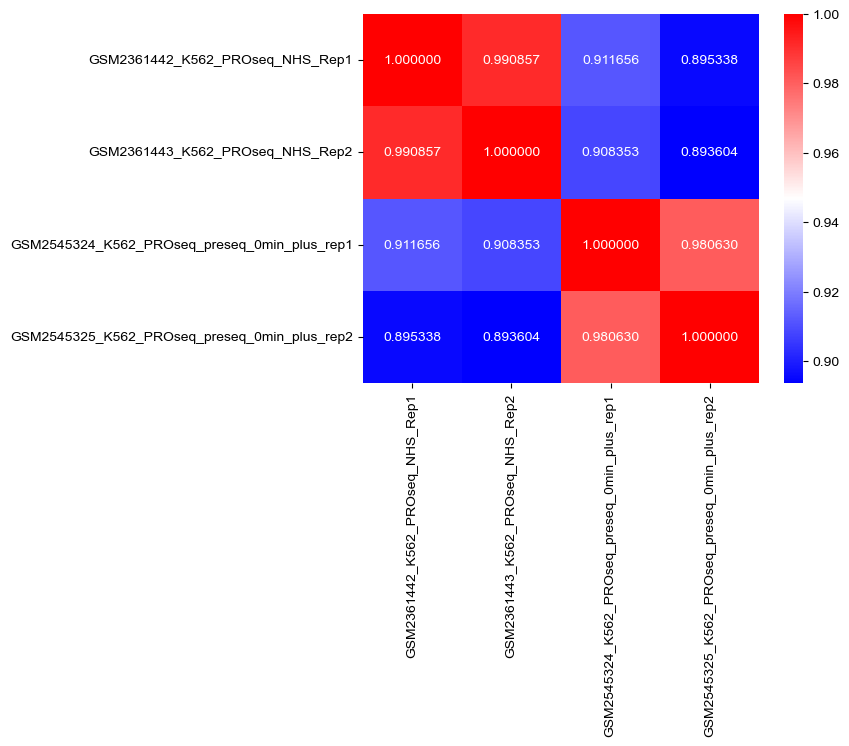

In [42]:
sns.heatmap(corr, cmap="bwr", annot=True, fmt='f')

# Transcription activity

In [45]:
with GtfFile("/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.sorted.gtf.gz") as f:
    genes = list(GtfGeneBuilder(f))

In [51]:
tmp = []
for g in genes:
    gtype = g.records['gene'][0].attributes['gene_type']
    if gtype == "protein_coding" or gtype == "lncRNA":
        tmp.append(g)
genes = tmp
print(len(genes))

37737


In [62]:
loader = ShiftLoader(genes)
tmp = []
for g in genes:
    keep = True
    for g2 in loader.fetch(chrom=g.chrom, start=g.start - 1000, end=g.end + 1000):
        if g2 is not g:
            keep = False
            break
    if keep:
        tmp.append(g)
genes1 = tmp
print(len(genes1))

11302


In [67]:
tmp = []
for g in genes1:
    gtype = g.records['gene'][0].attributes['gene_type']
    if gtype == "protein_coding":
        tmp.append(g)
genes2 = tmp
print(len(genes2))

6291


In [82]:
path1 = "results/08_bigwigs/GSM2361443_K562_PROseq_NHS_Rep2_norm_pos.bw"
path2 = "results/08_bigwigs/GSM2361443_K562_PROseq_NHS_Rep2_norm_neg.bw"
bw1 = pyBigWig.open(path1)
bw2 = pyBigWig.open(path2)
rows = []
for g in genes2:
    # print(g.format())
    gtype = g.records['gene'][0].attributes['gene_type']
    gname = g.records['gene'][0].attributes['gene_name']
    for t in g.transcripts:
        ttype = t.records['transcript'][0].attributes['transcript_type']
        tname = t.records['transcript'][0].attributes['transcript_name']
        if t.end - t.start < 1000:
            continue
        if t.strand == "+":
            vs = np.nan_to_num(bw1.values(t.chrom, t.start - 300, t.start - 100), 0)
            promotor_upstream = np.sum(vs) * 1000 / 200
            vs = np.nan_to_num(bw1.values(t.chrom, t.start + 300, t.start + 500), 0)
            promotor_downstream = np.sum(vs) * 1000 / 200
            vs = np.nan_to_num(bw1.values(t.chrom, t.start, t.start + 500), 0)
            five_genic = np.sum(vs) * 1000 / 500
            vs = np.nan_to_num(bw1.values(t.chrom, t.start + 300, t.end), 0)
            density = np.sum(vs) * 1000 / (t.end - t.start - 300)
        else:
            vs = np.nan_to_num(bw2.values(t.chrom, t.end + 100, t.end + 300), 0)
            promotor_upstream = np.sum(vs) * 1000 / 200
            vs = np.nan_to_num(bw2.values(t.chrom, t.end - 500, t.end - 300), 0)
            promotor_downstream = np.sum(vs) * 1000 / 200
            vs = np.nan_to_num(bw2.values(t.chrom, t.end - 500, t.end), 0)
            five_genic = np.sum(vs) * 1000 / 500
            vs = np.nan_to_num(bw2.values(t.chrom, t.start, t.end - 300), 0)
            density = np.sum(vs) * 1000 / (t.end - t.start - 300)
        row = [t.name, ttype, tname, g.name, gtype, gname, promotor_upstream, promotor_downstream, five_genic, density]
        rows.append(row)
bw1.close()
bw2.close()

In [173]:
m = pd.DataFrame(rows, columns=['TranscriptID', 'TranscriptType', 'TranscriptName', 'GeneID', 'GeneType', 'GeneName', 
                                'PromotorUpstream', 'PromotorDownstream', 'FiveGenic', 'GeneBody'])
m = m[m['TranscriptType'] == 'protein_coding']
# m = m[~m['GeneID'].duplicated()]
gids = []
for gid, n in Counter(m['GeneID']).items():
    if n == 1:
        gids.append(gid)
m1 = m[m['GeneID'].isin(gids)].copy()
print(len(m1))
m1.index = m1['GeneID']

1759


In [174]:
d = pd.read_csv("../1_FLAIRseq/reports/halflife_of_K562_50uM_3h.2TC.tsv", sep='\t')
d.index = d['GeneID']
d = d[d['Total'] >= 20]

In [175]:
s1 = d['TPM']
s2 = d['SynthesisRate']
s3 = m1['GeneBody']
df = pd.concat([s1, s2, s3], axis=1, join='inner')
df.columns = ['TPM', 'SynthesisRate', 'PRO-seq']
print(len(df))

143


                    TPM  SynthesisRate   PRO-seq
TPM            1.000000       0.358448  0.183013
SynthesisRate  0.358448       1.000000  0.514118
PRO-seq        0.183013       0.514118  1.000000


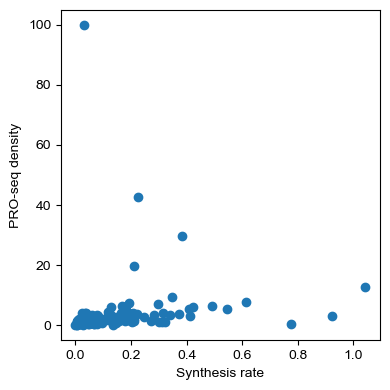

In [176]:
df1 = df[np.isfinite(df['SynthesisRate'])]
print(df1.corr(method='spearman'))
xs = df1['SynthesisRate']
ys = df1['PRO-seq']
plt.figure(figsize=(4, 4))
plt.scatter(xs, ys)
plt.xlabel("Synthesis rate")
plt.ylabel("PRO-seq density")
plt.tight_layout()
plt.show()

# Transcription activity (2024-11-20)

In [2]:
# Load transcripts
with BedFile('/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.transcripts.bed.gz') as f:
    transcripts = {t.name: t for t in f}
    anno = pd.read_csv('/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.tsv', sep='\t')
for tid, ttype, gid, gtype, gname in anno[['TranscriptID', 'TranscriptType', 'GeneID', 'GeneType', 'GeneName']].values:
    t = transcripts[tid]
    t.transcript_type = ttype
    t.gene_id = gid
    t.gene_type = gtype
    t.gene_name = gname
transcripts = list(sorted(transcripts.values()))

# Build genes
gid2transcripts = defaultdict(list)
for t in transcripts:
    gid2transcripts[t.gene_id].append(t)
genes = []
for gid, ts in gid2transcripts.items():
    g = GRange(chrom=ts[0].chrom, start=min([t.start for t in ts]), end=max(t.end for t in ts), name=gid, strand=ts[0].strand)
    g.gene_type = ts[0].gene_type
    g.gene_name = ts[0].gene_name
    g.transcripts = ts
    genes.append(g)
genes.sort()

In [12]:
chrom_transcripts = defaultdict(list)
for t in transcripts:
    chrom_transcripts[t.chrom].append(t)
    
path1 = 'results/09_bigwigs/GSM2361442_K562_PROseq_NHS_Rep1_norm_pos.bw'
path2 = 'results/09_bigwigs/GSM2361442_K562_PROseq_NHS_Rep1_norm_neg.bw'
bw1 = pyBigWig.open(path1)
bw2 = pyBigWig.open(path2)
rows = []
for chrom in chrom_transcripts.keys():
    print(chrom)
    ts = chrom_transcripts[chrom]
    covs1 = np.nan_to_num(bw1.values(chrom, 0, bw1.chroms()[chrom]), 0)
    covs2 = np.nan_to_num(bw2.values(chrom, 0, bw2.chroms()[chrom]), 0)
    for t in ts:
        promotor_upstream = None
        promotor_downstream = None
        five_genic = None
        density = None
        if t.strand == '+':
            vs = covs1[t.start-300:t.start-100]
            promotor_upstream = np.sum(vs) * 1000 / 200
            vs = covs1[t.start+300:t.start+500]
            promotor_downstream = np.sum(vs) * 1000 / 200
            vs = covs1[t.start:t.start+500]
            five_genic = np.sum(vs) * 1000 / 500
            if t.end - t.start > 300:
                vs = covs1[t.start+300:t.end]
                density = np.sum(vs) * 1000 / (t.end - t.start - 300)
        else:
            vs = covs2[t.end+100:t.end+300]
            promotor_upstream = np.sum(vs) * 1000 / 200
            vs = covs2[t.end-500:t.end-300]
            promotor_downstream = np.sum(vs) * 1000 / 200
            vs = covs2[t.end-500:t.end]
            five_genic = np.sum(vs) * 1000 / 500
            if t.end - t.start > 300:
                vs = covs2[t.start:t.end-300]
                density = np.sum(vs) * 1000 / (t.end - t.start - 300)
        row = [t.name, promotor_upstream, promotor_downstream, five_genic, density]
        rows.append(row)
bw1.close()
bw2.close()

chr1
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr2
chr20
chr21
chr22
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chrM


KeyError: 'chrM'

In [13]:
d = pd.DataFrame(rows, columns=['TranscriptID', 'PromoterUpstream', 'PromoterDownstream', 'FiveGenic', 'GeneBody'])
d

,TranscriptID,PromoterUpstream,PromoterDownstream,FiveGenic,GeneBody
0,ENST00000456328.2,0.0,0.0,0.000000,0.000000
1,ENST00000450305.2,0.0,0.0,0.000000,0.000000
2,ENST00000488147.1,0.0,0.0,0.000000,0.168552
3,ENST00000619216.1,0.0,0.0,0.260349,NaN
4,ENST00000473358.1,0.0,0.0,0.000000,0.026160
...,...,...,...,...,...
236127,ENST00000540522.6,0.0,0.0,0.000000,0.009495
236128,ENST00000639350.1,0.0,0.0,0.000000,0.000000
236129,ENST00000411324.1,0.0,0.0,0.000000,NaN
236130,ENST00000523795.4,0.0,0.0,0.000000,NaN
